## Обучение с учителем. Задача классификации

In [57]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings(action='ignore', category=RuntimeWarning)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.combine import SMOTEENN
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, 
    precision_score, recall_score, f1_score, ConfusionMatrixDisplay, RocCurveDisplay
)

### Чтение данных

In [30]:
data = pd.read_csv(f"../data/credit_card_fraud_filtered.csv")

data.head(5)

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud,high_price_anomaly
0,57.877857,0.311140,1.945940,1,1,0,0,0,0
1,10.829943,0.175592,1.294219,1,0,0,0,0,0
2,5.091079,0.805153,0.427715,1,0,0,1,0,0
3,2.247564,5.600044,0.362663,1,1,0,1,0,0
4,44.190936,0.566486,2.222767,1,1,0,1,0,0


In [31]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 884794 entries, 0 to 884793
Data columns (total 9 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   distance_from_home              884794 non-null  float64
 1   distance_from_last_transaction  884794 non-null  float64
 2   ratio_to_median_purchase_price  884794 non-null  float64
 3   repeat_retailer                 884794 non-null  int64  
 4   used_chip                       884794 non-null  int64  
 5   used_pin_number                 884794 non-null  int64  
 6   online_order                    884794 non-null  int64  
 7   fraud                           884794 non-null  int64  
 8   high_price_anomaly              884794 non-null  int64  
dtypes: float64(3), int64(6)
memory usage: 60.8 MB


### Выделение целевого признака и предикторов

In [32]:
y = data['fraud']
x = data.drop('fraud', axis=1)

#### Разбиение на обучающую и тестовую выборки с использованием стратификации

In [33]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, 
    test_size=0.15, 
    random_state=81, 
    stratify=y
)

In [34]:
x_train[:5]

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,high_price_anomaly
189042,52.252629,0.061874,0.705385,1,0,0,0,0
361532,2.903823,0.169253,0.538185,1,1,0,0,0
38365,39.065192,2.259835,2.276197,1,0,0,0,0
349705,11.520815,0.300404,0.534076,1,1,0,0,0
665313,120.382848,6.409485,0.337039,1,1,1,1,0


In [35]:
y_train[:5]

189042    0
361532    0
38365     0
349705    0
665313    0
Name: fraud, dtype: int64

In [36]:
y.value_counts()

fraud
0    828124
1     56670
Name: count, dtype: int64

Рассматриваем задачу бинарной классификации, так как целевой признак `fraud` принимает значения 0 или 1.

### Масштабирование данных

In [37]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

### Дисбаланс классов
#### Визуализация

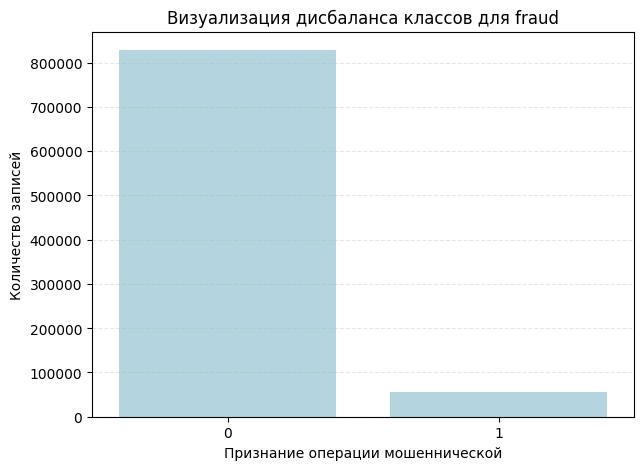

In [38]:
plt.figure(figsize=(7, 5))

sns.countplot(data, x='fraud', color='lightblue')

plt.title("Визуализация дисбаланса классов для fraud")
plt.xlabel("Признание операции мошеннической")
plt.ylabel("Количество записей")
plt.grid(axis='y', linestyle='--', alpha=0.3)

#### Балансировка классов при помощи метода `SMOTEENN`

Данный метод основан на `SMOTE`, который создает синтетические данные, однако также использует `ENN` (редактирование ближайших соседей). `SMOTE` находит близкие объекты миноритарного класса в пространстве признаков и создает между ними "синтетические" новые точки. Edited Nearest Neighbors берет каждую точку и смотрит на её k ближайших соседей (обычно 3). Если большинство соседей принадлежат к другому классу, точка удаляется. 

Альтернативным вариантом было использование метода `SMOTETomek`, который находит и удаляет «связи Томека» (пары близкорасположенных объектов разных классов). Однако для данной задачи был выбран более агрессивный метод `SMOTEENN`, так как он позволяет провести более жесткую очистку границ между классами, что способствует повышению точности классификации в условиях зашумленности данных.

Text(0.5, 1.0, 'Визуализация признаков distance_from_home и ratio_to_median_purchase_price')

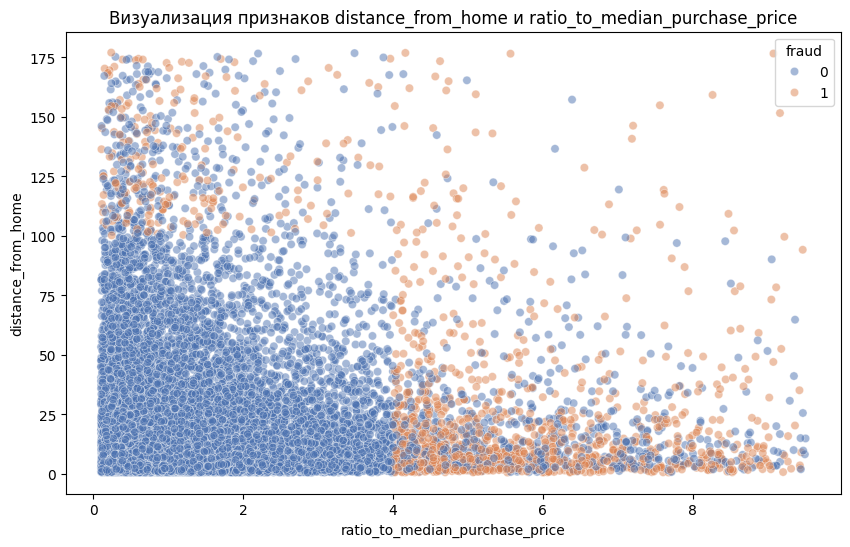

In [39]:
data_sample = data.sample(20_000, random_state=81)


plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data_sample,
    x='ratio_to_median_purchase_price',
    y='distance_from_home',
    hue='fraud',
    palette='deep',
    alpha=0.5
)

plt.title('Визуализация признаков distance_from_home и ratio_to_median_purchase_price')

Визуализация признаков `distance_from_home` и `ratio_to_median_purchase_price` показала значительное перекрытие классов (overlap), что тоже способствует выбору `SMOTEENN`

In [40]:
sme = SMOTEENN(random_state=81, n_jobs=-1)
x_train_res, y_train_res = sme.fit_resample(x_train_scaled, y_train)

/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/imblearn/over_sampling/_smote/base.py:370: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already se

Посмотрим, как изменилась обучающая выборка после применения метода.

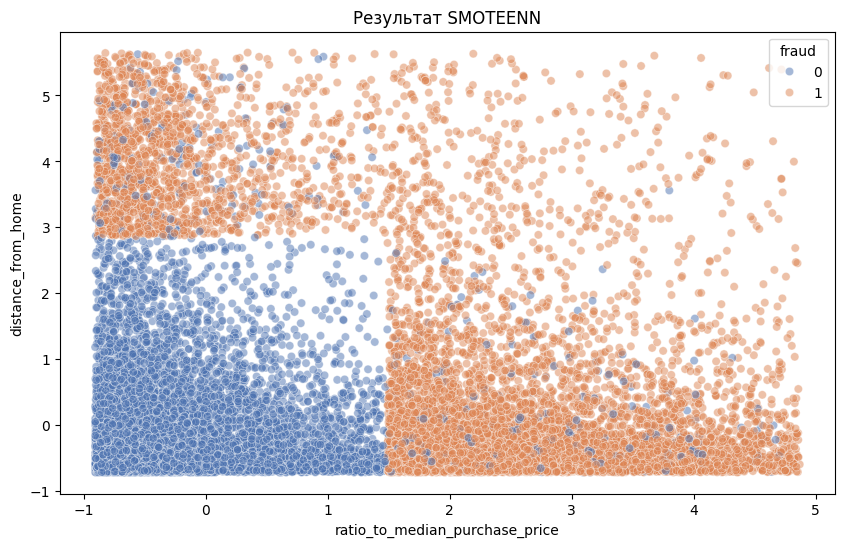

fraud
1    703848
0    702759
Name: count, dtype: int64

In [41]:
data_res = pd.DataFrame(x_train_res, columns=x.columns)
data_res['fraud'] = y_train_res

res_sample = data_res.sample(20_000, random_state=81)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=res_sample,
    x='ratio_to_median_purchase_price', 
    y='distance_from_home',
    hue='fraud',
    palette='deep',
    alpha=0.5
)

plt.title('Результат SMOTEENN')
plt.show()

data_res['fraud'].value_counts()

На графике после применения `SMOTEENN` наблюдается появление четких границ между классами. Это результат работы алгоритма `ENN`, который удалил объекты, находящиеся в зоне высокого перекрытия классов (overlap). Несмотря на визуальное изменение плотности данных, такая предобработка позволяет классификатору выстроить более устойчивую разделяющую гиперплоскость, минимизируя риск переобучения на шуме.

### Решение задачи классификации
#### Логистическая регрессия с использованием `GridSearchCV`

Сбор метрик, вывод `classification_report`, `confusion_matrix`, `roc_curve`.

In [81]:
def metrics(model, x_test, y_test, model_name):
    y_pred = model.predict(x_test)

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    }

    print(classification_report(y_test, y_pred))

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0])
    ax[0].set_title(f"Confusion Matrix")
    RocCurveDisplay.from_predictions(y_test, y_pred, ax=ax[1])
    ax[1].set_title(f"ROC Curve")
    
    return metrics 

results = []

Обучение LogisticRegression с использование `KFold` для кросс-валидации и `GridSearchCV` для подбора гиперпараметров.

In [59]:
kf = KFold(n_splits=5, random_state=81, shuffle=True)

lr = LogisticRegression(
    penalty='elasticnet',
    random_state=81,
    solver='saga',
    max_iter=1000,
    n_jobs=-1
)

param_grid = {
    'C' : [0.1, 1, 10],
    'l1_ratio' : [0.2, 0.5, 0.8]
}

grid_search_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    scoring='f1',
    n_jobs=-1,
    cv=kf
)

grid_search_lr.fit(x_train_res, y_train_res)

/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/

GridSearchCV(cv=KFold(n_splits=5, random_state=81, shuffle=True),
             estimator=LogisticRegression(max_iter=1000, n_jobs=-1,
                                          penalty='elasticnet', random_state=81,
                                          solver='saga'),
             n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'l1_ratio': [0.2, 0.5, 0.8]},
             scoring='f1')

Вывод полученных результатов.

              precision    recall  f1-score   support

           0       1.00      0.95      0.97    124219
           1       0.57      0.98      0.72      8501

    accuracy                           0.95    132720
   macro avg       0.78      0.96      0.85    132720
weighted avg       0.97      0.95      0.96    132720



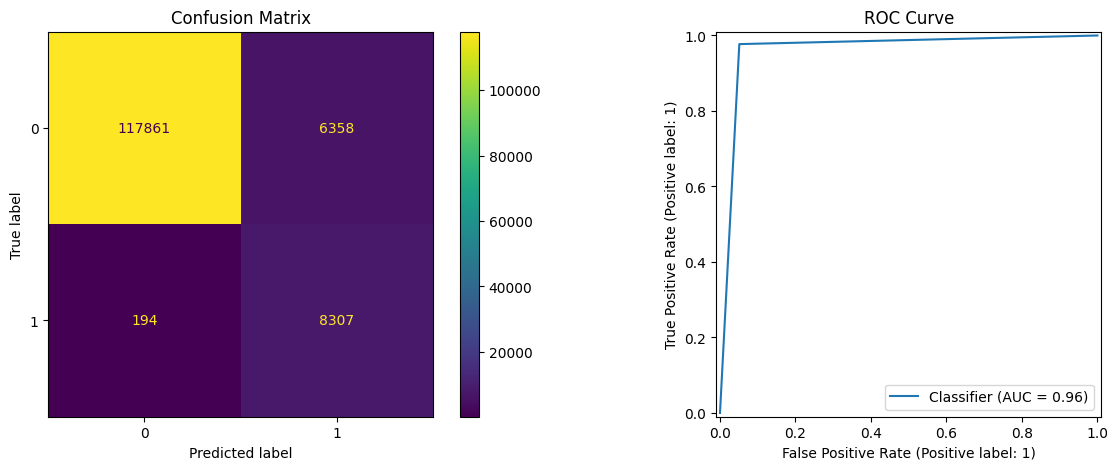

In [82]:
lr_results = metrics(
    grid_search_lr.best_estimator_, 
    x_test_scaled, 
    y_test, 
    model_name="Logistic Regression (ElasticNet)"
)

results.append(lr_results)

In [55]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression (ElasticNet),0.950633,0.566451,0.977179,0.717172
